# Begin

In [1]:
# @launchit.collected

In [2]:
import os # @launchit.collect
import sys # @launchit.collect
import copy
from collections import namedtuple, defaultdict # @launchit.collect
import json
import datetime
import pprint
from functools import cache
import re
import pickle
from unittest.mock import Mock
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import IPython
from enum import Flag, StrEnum, auto # @launchit.collect
import multiprocessing as mp

from tqdm.notebook import tqdm

import lark # @launchit.collect

import numpy as np
import cupy as cp
import einops
import scipy.linalg
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim
from torch.utils.data import DataLoader, StackDataset
from torchvision import datasets

import optuna 
from optuna.storages import JournalStorage 
from optuna.storages.journal import JournalFileBackend 
from optuna.trial import TrialState

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
from utils import * # @launchit.collect
from logging_utils import *
from image_utils import *
from basis_pursuit import *
from model_registry import *
from torch_helpers import *
import launchit # @launchit.disable
import optuna_multiprocessing  # @launchit.collect
from hp_utils import *
from metrics_collector import RmqSummaryWriter
from autoincrement import Autoincrement

# Init

In [3]:
ArrayUtils.init()
LOG = Logging.get()
RNG = np.random.default_rng()
METRICS_SUITE = defaultdict(list)

class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, subproject_path, data_path, mnist_path, private_data_path, run_path, ' + 
                    'self_fname, self_name, ' +
                    'subproject_name,' +
                    'is_cuda, cuda_device, exec_mode, is_interactive')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    subproject_path=os.path.abspath('.'),
    data_path=os.path.join(project_root_path, 'data'),
    mnist_path=os.path.join(project_root_path, 'data', 'mnist'),
    private_data_path=None,
    run_path=None,
    self_fname=None,
    self_name=None,
    subproject_name=None,
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    exec_mode=ExecMode.MASTER_NOTEBOOK,
    is_interactive=True,
)

if IPython.get_ipython() is None:
    module_fname = __file__
    module_basename = os.path.basename(module_fname)
    module_name, _ = os.path.splitext(module_basename)
    
    CONFIG = CONFIG._replace(self_fname=module_fname, self_name=module_name)
    CONFIG = CONFIG._replace(exec_mode=ExecMode.LAUNCH_MODULE)
else:
    with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
        notebook_fname = json.load(cf)['jupyter_session']
        notebook_basename = os.path.basename(notebook_fname)
        notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    
        m = re.match(r'(\w+)-Copy\d+$', notebook_name)
    
        if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook

        CONFIG = CONFIG._replace(self_fname=notebook_fname, self_name=notebook_name)
        
        is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
        CONFIG = CONFIG._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)

CONFIG = CONFIG._replace(is_interactive=CONFIG.exec_mode != ExecMode.LAUNCH_MODULE)

LOG.app_name = CONFIG.self_name
LOG.enable('syslog', not CONFIG.is_interactive)
LOG.enable('stdout', CONFIG.is_interactive)

CONFIG = CONFIG._replace(subproject_name=os.path.basename(os.path.dirname(CONFIG.self_fname)))
CONFIG = CONFIG._replace(run_path=os.path.join(project_root_path, 'run', CONFIG.subproject_name))
CONFIG = CONFIG._replace(private_data_path=os.path.join(CONFIG.data_path, CONFIG.subproject_name))
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)

os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)

CONFIG=
{'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'subproject_path': '/home/misha/dev/mine/neurovision/15_transformer',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'mnist_path': '/home/misha/dev/mine/neurovision/data/mnist',
 'private_data_path': '/home/misha/dev/mine/neurovision/data/15_transformer',
 'run_path': '/home/misha/dev/mine/neurovision/run/15_transformer',
 'self_fname': '/home/misha/dev/mine/neurovision/15_transformer/15_vocab_02.ipynb',
 'self_name': '15_vocab_02',
 'subproject_name': '15_transformer',
 'is_cuda': True,
 'cuda_device': 'cuda',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



In [4]:
# @launchit.disable
# @launchit.collect
class LaunchGoal(StrEnum):
    UNSPECIFIED = auto()
    TRAIN_MODEL = auto()

class LaunchGoalObj(namedtuple('LaunchGoalObj', 'goal, model_group_uri, model_name, model_version, model_main_asset_fname')):
    def matches(self, *g):
        if CONFIG.exec_mode == ExecMode.MASTER_NOTEBOOK:
            return True
            
        if g and isinstance(g[0], list):
            assert len(g) == 1
            return self.goal in g[0]

        return self.goal in g

LAUNCH_GOAL = LaunchGoalObj(
    goal=LangUtils.from_str(LaunchGoal, '${LAUNCH_GOAL}', LaunchGoal.UNSPECIFIED),
    model_group_uri='${MODEL_GROUP_URI}',
    model_name='${MODEL_NAME}',
    model_version=LangUtils.from_str(int, '${MODEL_VERSION}', 0),
    model_main_asset_fname='${LAUNCHIT_FNAME}',
)
# @launchit.stop

LAUNCH_GOAL = LAUNCH_GOAL._replace(goal=LaunchGoal.UNSPECIFIED)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_group_uri=f'{CONFIG.project_root_uri}.{CONFIG.subproject_name}')
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_name=CONFIG.self_name)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_version=0)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_main_asset_fname=CONFIG.self_fname)
# @launchit.stop

LOG(f'LAUNCH_GOAL=\n{pprint.pformat(LAUNCH_GOAL._asdict(), sort_dicts=False)}', when=CONFIG.is_interactive)
LOG(f'LAUNCH_GOAL={LAUNCH_GOAL._asdict()}', when=not CONFIG.is_interactive)

LAUNCH_GOAL=
{'goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'model_group_uri': 'com.develorium.neurovision.15_transformer',
 'model_name': '15_vocab_02',
 'model_version': 0,
 'model_main_asset_fname': '/home/misha/dev/mine/neurovision/15_transformer/15_vocab_02.ipynb'}


# Hyperparameters

In [5]:
# @launchit.disable
# @launchit.collect
@dataclass
class Hyperparameters:
    random_seed: int = None
    # dataset params
    images_preprocessing: str = None
    patch_size: int = None
    # model params
    vocab_size: int = None
    weights_clamp: tuple = None
    # training params
    batch_size: int = None
    epochs_count: int = None
    optimizer: str = None
    learn_rate: float | str = None

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

HP = Hyperparameters()
HP.random_seed = 42

# Launch

## new_model_registry

In [6]:
def new_model_registry(is_real=None):
    is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
    is_real = is_real if is_real is not None else is_launch

    if not is_real:
        mr = Mock()
        mr.register_model.return_value = 0
        return mr
        
    return ModelRegistry(LAUNCH_GOAL.model_group_uri)

## new_summary_writer

In [7]:
def new_summary_writer(log_dir, is_real=None):
    is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
    is_real = is_real if is_real is not None else is_launch

    if not is_real:
        sw = Mock()
        sw.flush.side_effect = sw.reset_mock # to get rid of all recorded call_args_list, which might be heavy (e.g. add_figure)
        return sw
    
    return RmqSummaryWriter(log_dir)

## Bootstrap

In [8]:
optuna_trial = optuna_multiprocessing.get_trial()
optuna_trial_subdir_name = ''

if optuna_trial is not None:
    optuna_trial.set_user_attr('MODEL_VERSION', LAUNCH_GOAL.model_version)
    study_serial = optuna_trial.user_attrs['STUDY_SERIAL']
    optuna_trial_subdir_name = f'opt_{study_serial}'
    LOG(f'Optuna {optuna_trial.number=}, {optuna_trial.user_attrs=}')

LOG(f'HP={HP._asdict()}', when=not CONFIG.is_interactive)
    
if HP.random_seed is not None:
    torch.manual_seed(HP.random_seed)
    RNG = np.random.default_rng(HP.random_seed)    
    LOG(f'Random seed={HP.random_seed}')

model_registry = new_model_registry()
model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, CONFIG.self_fname, replace=True)
    
meta = dict(
    optuna_trial_number=getattr(optuna_trial, 'number', None),
    hypers=HP._asdict(), 
    config=CONFIG._asdict(), 
)

with io.StringIO() as b:
    json.dump(meta, b)
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='json', asset_classifier='meta', replace=True)

summary_log_dir = LAUNCH_GOAL.model_name
summary_log_dir = os.path.join(summary_log_dir, optuna_trial_subdir_name) if optuna_trial_subdir_name != '' else summary_log_dir 
summary_log_dir = os.path.join(summary_log_dir, str(LAUNCH_GOAL.model_version))
LOG(f'Tensorboard run={summary_log_dir}')
summary_writer = new_summary_writer(log_dir=summary_log_dir)
summary_writer.add_text('hypers', pprint.pformat(HP._asdict(), sort_dicts=False), 1)
summary_writer.add_text('config', pprint.pformat(CONFIG._asdict(), sort_dicts=False), 1)

Random seed=42
Tensorboard run=15_vocab_02/0


<Mock name='mock.add_text()' id='130927952582400'>

# Dataset

In [9]:
# @launchit.disable
# @launchit.collect_1
HP.images_preprocessing = 'UNINORM' # NONE, UNINORM, SAMPLE_WISE, MIN_MAX, STANDARDIZE, ZCA_WHITEN, ZCA_HFR30_WHITEN
HP.patch_size = 5

In [10]:
IMAGES, _ = get_mnist_images(CONFIG.mnist_path, 'TRAIN')
h = IMAGES.shape[1]
IMAGES = einops.rearrange(IMAGES, 'b h w -> b (h w)')
IMAGES, IMAGES_SCALER = preprocess_images(IMAGES, HP.images_preprocessing)
IMAGE_STDS = IMAGES.std(axis=1)
IMAGES = einops.rearrange(IMAGES, 'b (h w) -> b h w', h=h)

# LAUNCH_GOAL.TRAIN_MODEL

## Configure

In [45]:
# @launchit.disable
# @launchit.collect_1
HP.vocab_size = 100
HP.weights_clamp = None
HP.batch_size = 100
HP.epochs_count = 2
HP.optimizer = 'Adam'
HP.learn_rate = '0.0005,plateau()'
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'random_seed': 42,
 'images_preprocessing': 'STANDARDIZE',
 'patch_size': 7,
 'vocab_size': 100,
 'batch_size': 100,
 'epochs_count': 2,
 'optimizer': 'Adam',
 'learn_rate': '0.0005,plateau()'}


## Create

In [46]:
W = torch.randn(HP.patch_size**2, HP.vocab_size, device=CONFIG.cuda_device)

if HP.images_preprocessing == 'UNINORM':
    torch.nn.init.uniform_(W)
elif HP.images_preprocessing == 'STANDARDIZE':
    torch.nn.init.normal_(W, std=0.01)
else:
    assert False, f'Unsupported {HP.images_preprocessing=}'
    
W = nn.Parameter(W)
lr_params = hp_parse_learn_rate(HP.learn_rate)
optimizer = getattr(torch.optim, HP.optimizer)([W], lr=lr_params.learn_rate)
lr_scheduler = LrSchedulerWrapper(optimizer, lr_params)
data_loader = DataLoader(torch.tensor(IMAGES).to(CONFIG.cuda_device), batch_size=HP.batch_size, shuffle=True)

## Train

In [46]:
for epoch in tqdm(range(HP.epochs_count + 1), desc='Epoch', disable=not CONFIG.is_interactive):
    with LOG.auto_prefix('EPOCH', epoch):
        epoch_loss = dict(all=0, wz=0)
        epoch_loss_denom = 0
    
        for batch in data_loader:
            optimizer.zero_grad()
            
            batch = einops.rearrange(batch, 'b h w -> b 1 h w')
            patches = F.unfold(batch, kernel_size=HP.patch_size) # create patches in a way nn.Conv2d does
            patches = einops.rearrange(patches, 'b p xy -> (b xy) p')
            
            with torch.no_grad():
                Z = bp_batch_solo(patches, W)

            patches_hat = Z @ W.T 
            wz_loss = F.mse_loss(patches_hat, patches)
            loss = wz_loss

            if epoch > 0: # first run is a dry run to get losses baseline
                loss.backward()
                optimizer.step()

            if HP.weights_clamp is not None:
                with torch.no_grad():
                    W.clamp_(min=HP.weights_clamp[0], max=HP.weights_clamp[1])
    
            for k, l in zip(('all', 'wz'), (loss, wz_loss)):
                epoch_loss[k] += l.item() * len(batch)
                
            epoch_loss_denom += len(batch)

        for k in epoch_loss:
            epoch_loss[k] = epoch_loss[k] / epoch_loss_denom
            
        lr_scheduler.step(epoch_loss['all'])
    
        assert epoch_loss_denom > 0

        # Report metrics and upload figures
        concat_log = []
        
        for k, l in epoch_loss.items():
            k = f'loss_{k}'
            summary_writer.add_scalar(k, l, epoch)
            METRICS_SUITE[k].append(l)
            concat_log.append(f'{k}={l:.4g}')
            
        LOG(', '.join(concat_log), when=not CONFIG.is_interactive)

        if optuna_trial is not None:
            # https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html#optuna.trial.Trial.report:
            # > If this method is called multiple times at the same step in a trial, the reported value only the first time is stored 
            # > and the reported values from the second time are ignored.
            # In other words calling report for fold other than the first one does nothing except producing tons of warnings in console. 
            # As such only the first fold is indicative
            optuna_trial.report(epoch_loss['all'], epoch) 
    
            if optuna_trial.should_prune():
                # Despite written in docs OPTUNA_TRIAL.should_prune is not idempotent - consequent calls could lead
                # to different responses. Perhapse this is due to influence of concurrent trials running which could change
                # pruner decision. As such cache pruning result so it's immutable
                optuna_trial.set_user_attr('IS_PRUNED', True)
                LOG(f'Optuna pruning condition encountered. Stopping training')
                break
    
        upload_figures = True
    
        if upload_figures and ((epoch % 20) == 0 or (epoch == HP.epochs_count)):
            # Upload vocab images
            dict_items_in_row = 8
            max_dict_items_to_show = 100
            dict_items = W.detach().cpu().T
            rows_count = int(np.ceil(min(max_dict_items_to_show, len(dict_items)) / dict_items_in_row))
            fig, axes = plt.subplots(rows_count, dict_items_in_row, subplot_kw={'yticks': [], 'xticks': []})
            for ax in axes.ravel(): ax.set_axis_off()
            fig.set_figwidth(16)
            fig.set_figheight(rows_count * 1.5)
            
            for i, (d, ax) in enumerate(zip(dict_items, axes.ravel())):
                ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
                im = ax.imshow(ArrayUtils.v2sm(d))
                fig.colorbar(im, ax=ax)
            
            fig.tight_layout()
            summary_writer.add_figure(f'vocab', fig, epoch, close=False)
            plt.close(fig)
            LOG('Figure "vocab" uploaded', when=not CONFIG.is_interactive)
    
            # Upload examples
            if epoch == 0:
                example_patches = [extract_image_patch(IMAGES, IMAGE_STDS, HP.patch_size, rng=RNG) for _ in range(10)]
                example_inds = list(map(lambda p: f'#{p.image_ind}, ({p.i_off},{p.j_off})', example_patches))
                example_patches = np.array(list(map(lambda p: p.patch, example_patches)))
                example_patches = einops.rearrange(example_patches, 'b h w -> b (h w)')
    
            fig, axes = plt.subplots(3, len(example_patches))
            fig.set_figwidth(16)
            fig.set_figheight(len(axes) * 1.8)
            for ax in axes.ravel(): ax.set_axis_off()
            np_W = W.detach().cpu().numpy()

            with torch.no_grad(): 
                example_solver_z_list = bp_batch_solo(example_patches, np_W)
            
            for example_ind, patch, solver_z, (ax0, ax11, ax12) in zip(example_inds, example_patches, example_solver_z_list, axes.T):
                ax0.set_title(example_ind, fontdict=dict(fontsize=10))
                ax0.imshow(ArrayUtils.v2sm(patch))
                
                solver_patch = np_W @ solver_z
                solver_l = F.mse_loss(torch.tensor(solver_patch), torch.tensor(patch)).item()
                ax11.set_title(f'l={solver_l:.2f}', fontdict=dict(fontsize=10))
                ax11.imshow(ArrayUtils.v2sm(solver_patch))
                ax12.set_title(f'vocab item #{np.argmax(solver_z)}', fontdict=dict(fontsize=10))
                ax12.bar(np.arange(len(solver_z)), solver_z)

            fig.tight_layout()
            summary_writer.add_figure(f'examples', fig, epoch, close=False) 
            plt.close(fig) # manual closing because summar_writer may be in Mock mode leaving fig unclosed
            LOG('Figure "examples" uploaded', when=not CONFIG.is_interactive)
            
        summary_writer.flush()

Epoch:   0%|          | 0/3 [00:00<?, ?it/s]

## Visualize

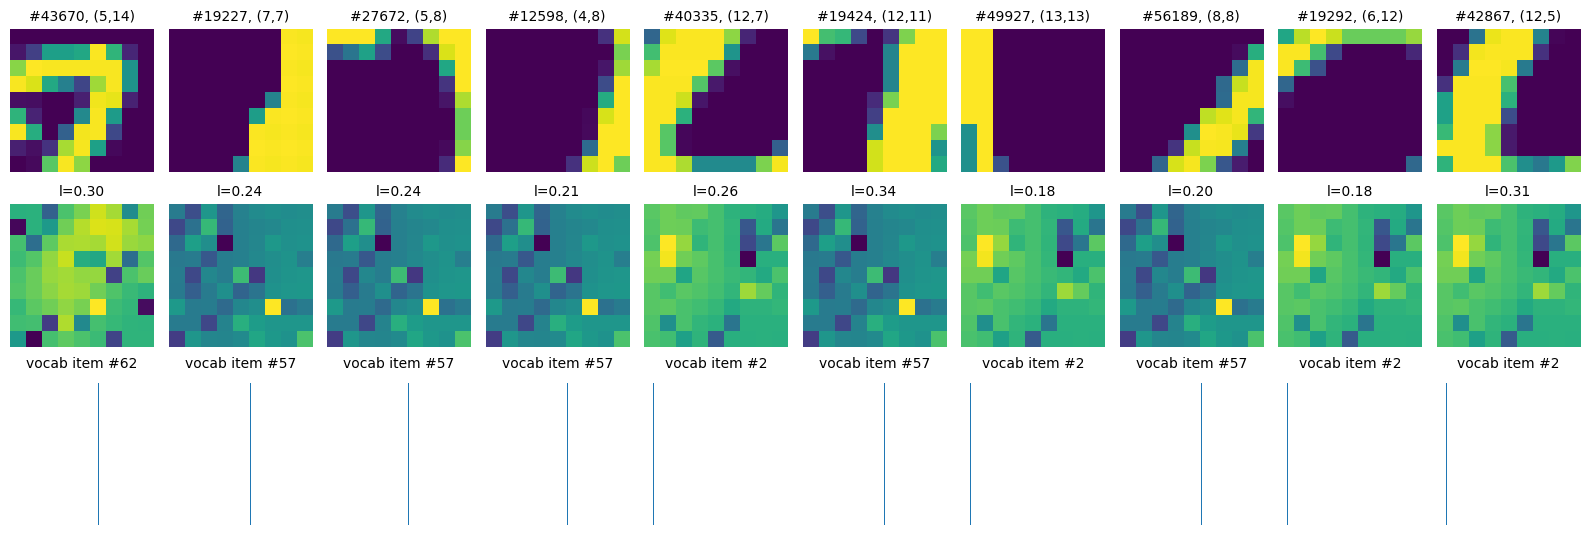

In [56]:
# @launchit.disable
example_patches = [extract_image_patch(IMAGES, IMAGE_STDS, HP.patch_size, rng=RNG) for _ in range(10)]
example_inds = list(map(lambda p: f'#{p.image_ind}, ({p.i_off},{p.j_off})', example_patches))
example_patches = np.array(list(map(lambda p: p.patch, example_patches)))
example_patches = einops.rearrange(example_patches, 'b h w -> b (h w)')
fig, axes = plt.subplots(3, len(example_inds))
fig.set_figwidth(16)
fig.set_figheight(len(axes) * 1.8)
for ax in axes.ravel(): ax.set_axis_off()
np_W = W.detach().cpu().numpy()

with torch.no_grad(): 
    example_solver_z_list = bp_batch_solo(example_patches, np_W)
    
for example_ind, patch, solver_z, (ax0, ax11, ax12) in zip(example_inds, example_patches, example_solver_z_list, axes.T):
    ax0.set_title(example_ind, fontdict=dict(fontsize=10))
    ax0.imshow(ArrayUtils.v2sm(patch))
    
    solver_patch = np_W @ solver_z
    solver_l = F.mse_loss(torch.tensor(solver_patch), torch.tensor(patch)).item()
    ax11.set_title(f'l={solver_l:.2f}', fontdict=dict(fontsize=10))
    ax11.imshow(ArrayUtils.v2sm(solver_patch))
    ax12.set_title(f'vocab item #{np.argmax(solver_z)}', fontdict=dict(fontsize=10))
    ax12.bar(np.arange(len(solver_z)), solver_z)

fig.tight_layout()

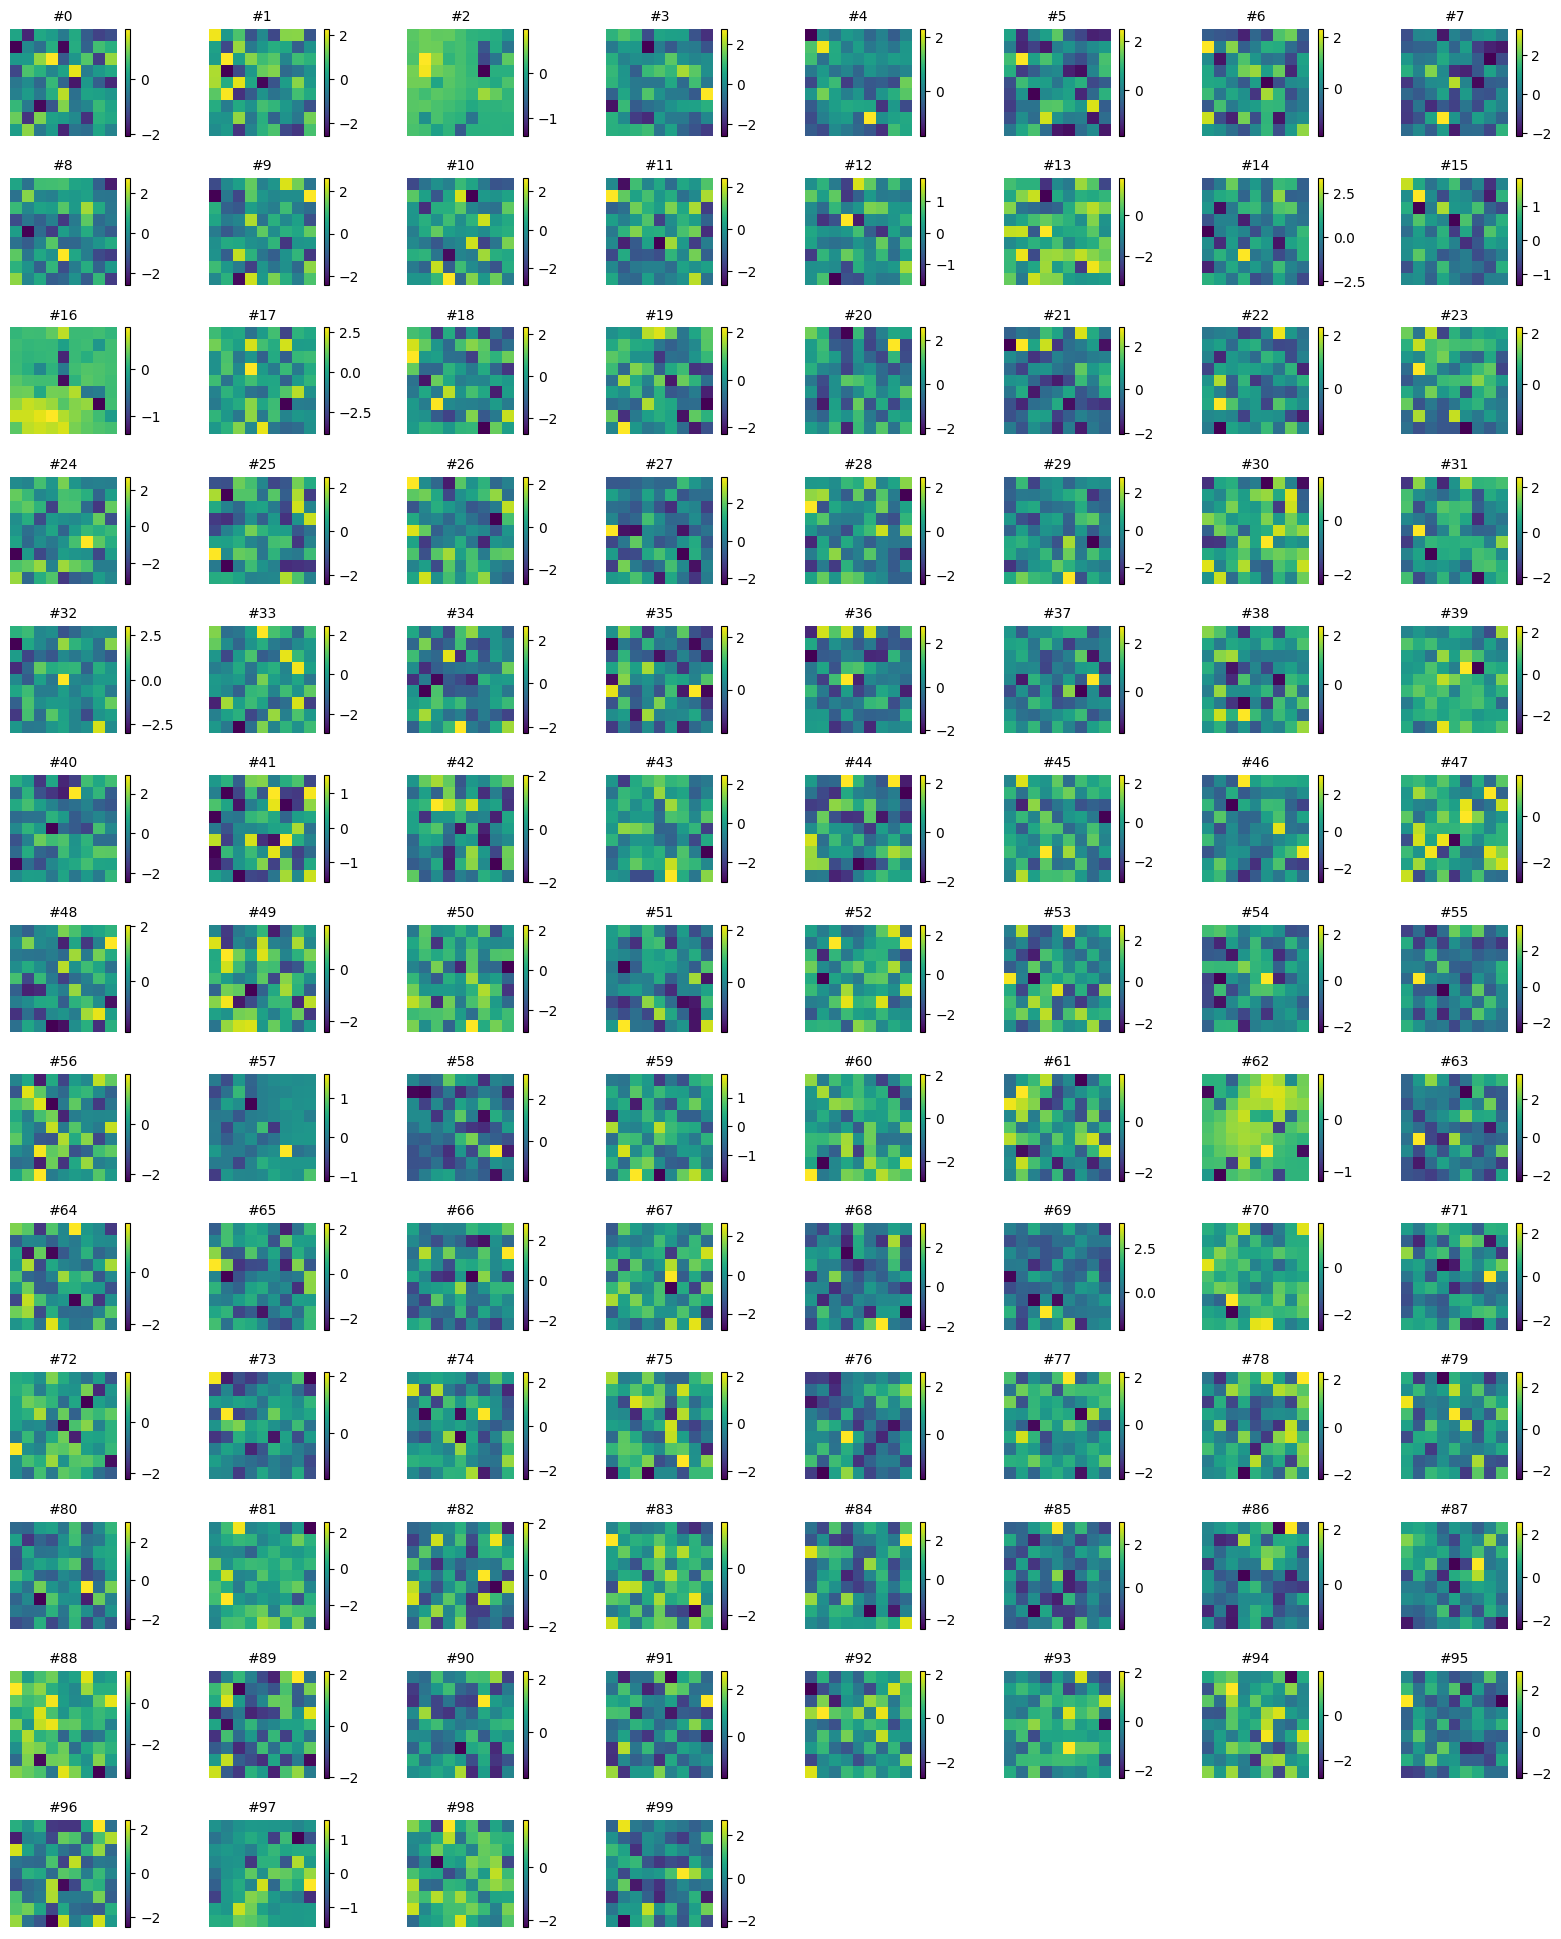

In [51]:
# @launchit.disable
dict_items_in_row = 8
max_dict_items_to_show = 100
dict_items = W.detach().cpu().T
rows_count = int(np.ceil(min(max_dict_items_to_show, len(dict_items)) / dict_items_in_row))
fig, axes = plt.subplots(rows_count, dict_items_in_row, subplot_kw={'yticks': [], 'xticks': []})
for ax in axes.ravel(): ax.set_axis_off()
fig.set_figwidth(16)
fig.set_figheight(rows_count * 1.5)

for i, (d, ax) in enumerate(zip(dict_items, axes.ravel())):
    ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
    im = ax.imshow(ArrayUtils.v2sm(d))
    fig.colorbar(im, ax=ax)

fig.tight_layout()

## Save

In [151]:
model_registry = new_model_registry()

with io.BytesIO() as b:
    torch.save({
        'model_state_dict': None,
        'optimizer_state_dict': optimizer.state_dict(),
        'hypers': HP._asdict(),
    }, b)
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='pt', asset_classifier='main', replace=True)

with io.BytesIO() as b:
    np.save(b, W.detach().cpu().numpy().T)
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='npy', asset_classifier='vocab', replace=True)

## Save Optuna trial result

In [121]:
optuna_trial = optuna_multiprocessing.get_trial()

if optuna_trial is not None:
    if 'IS_PRUNED' in optuna_trial.user_attrs:
        raise optuna.exceptions.TrialPruned()

    if not METRICS_SUITE:
        LOG(f'Empty metrics suite. Cancelling model')
        optuna_multiprocessing.save_trial_result(0)
    else:
        match LAUNCH_GOAL.goal:
            case LaunchGoal.TRAIN_MODEL:
                last_loss_all = METRICS_SUITE['loss_all'][-1]
                optuna_multiprocessing.save_trial_result(last_loss_all)
                LOG(f'Train objective result={last_loss_all}')
            case _:
                assert False, f'Unsupported {LAUNCH_GOAL.goal=}'

# Launch creation

## TRAIN_MODEL

In [11]:
# @launchit.disable
launchit_t0 = time.time()

In [15]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    model_version = int(Autoincrement.get(f'{LAUNCH_GOAL.model_group_uri}.{LAUNCH_GOAL.model_name}'))
    assert model_version > 0, model_version
    model_registry_obj = new_model_registry(is_real=True)
    model_registry_obj.register_model(LAUNCH_GOAL.model_name, model_version)
    LOG(f'Model instance registered, version={model_version}')
    
    expandvars = dict(
        PROJECT_ROOT_PATH=CONFIG.project_root_path,
        MODEL_GROUP_URI=LAUNCH_GOAL.model_group_uri,
        MODEL_NAME=LAUNCH_GOAL.model_name,
        MODEL_VERSION=model_version,
        LAUNCH_GOAL=LaunchGoal.TRAIN_MODEL.value,
    )
    launch_notebook_fname = launchit.launchit(CONFIG.self_fname, launch_serial=model_version, expandvars=expandvars, collect_inds=[1])
    LOG(f'Created launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Model instance registered, version=15
Creating /home/misha/dev/mine/neurovision/15_transformer/15_vocab_02-launch15.ipynb
Created launch notebook "/home/misha/dev/mine/neurovision/15_transformer/15_vocab_02-launch15.ipynb"


## Optuna (model selection)

### Templates

In [45]:
# @launchit.disable
# @launchit.collect_2
optuna_trial = optuna_multiprocessing.get_trial()

if optuna_trial is not None:
    study_serial = optuna_trial.user_attrs['STUDY_SERIAL']
    
    match study_serial:
        case 1:
            HP = Hyperparameters()
            HP.random_seed = 42
            HP.images_preprocessing = 'UNINORM' # NONE, UNINORM, SAMPLE_WISE, MIN_MAX, STANDARDIZE, ZCA_WHITEN, ZCA_HFR30_WHITEN
            HP.patch_size = 5
            HP.patches_count = 50_000
            HP.basis_pursuit_solver = 'SOLO'
            HP.vocab_size = 50
            HP.kx_nonlinearity = 'Sigmoid'
            wz_to_kx_odds = optuna_trial.suggest_int('wz_to_kx_odds', 1, 99)
            HP.wz_loss_weight = wz_to_kx_odds / 100
            HP.kx_loss_weight = (100 - wz_to_kx_odds) / 100
            HP.z_sparsity_loss_weight = 1
            HP.with_basis_norm = False
            HP.batch_size = 100
            HP.epochs_count = 50
            HP.optimizer = 'Adam'
            HP.learn_rate = '0.0005'
        case 2:
            HP = Hyperparameters()
            HP.random_seed = 42
            HP.images_preprocessing = 'UNINORM' # NONE, UNINORM, SAMPLE_WISE, MIN_MAX, STANDARDIZE, ZCA_WHITEN, ZCA_HFR30_WHITEN
            HP.patch_size = 5
            HP.patches_count = 50_000
            HP.basis_pursuit_solver = 'SOLO'
            HP.vocab_size = 50
            HP.kx_nonlinearity = 'Sigmoid'
            loss_weights = np.array([
                optuna_trial.suggest_float('wz_loss_weight', 0, 1),
                optuna_trial.suggest_float('kx_loss_weight', 0, 1),
                optuna_trial.suggest_float('kx_sparsity_loss_weight', 0, 1),
                optuna_trial.suggest_float('z_sparsity_loss_weight', 0, 1),
            ])
            loss_weights = loss_weights / np.linalg.norm(loss_weights)
            HP.wz_loss_weight = loss_weights[0]
            HP.kx_loss_weight = loss_weights[1]
            HP.kx_sparsity_loss_weight = loss_weights[2]
            HP.z_sparsity_loss_weight = loss_weights[3]
            HP.with_basis_norm = False
            HP.batch_size = 100
            HP.epochs_count = 50
            HP.optimizer = 'Adam'
            HP.learn_rate = '0.0005'
        case 3:
            HP = Hyperparameters()
            HP.random_seed = 42
            HP.images_preprocessing = 'UNINORM' # NONE, UNINORM, SAMPLE_WISE, MIN_MAX, STANDARDIZE, ZCA_WHITEN, ZCA_HFR30_WHITEN
            HP.patch_size = 5
            HP.patches_count = 50_000
            HP.basis_pursuit_solver = 'SOLO'
            HP.vocab_size = 50
            HP.kx_nonlinearity = 'Sigmoid'
            HP.with_gain = False
            loss_weights = np.array([
                optuna_trial.suggest_float('wz_loss_weight', 0, 1),
                optuna_trial.suggest_float('kx_loss_weight', 0, 1),
                optuna_trial.suggest_float('kx_sparsity_loss_weight', 0, 1),
                optuna_trial.suggest_float('z_sparsity_loss_weight', 0, 1),
            ])
            loss_weights = loss_weights / np.linalg.norm(loss_weights)
            HP.wz_loss_weight = loss_weights[0]
            HP.kx_loss_weight = loss_weights[1]
            HP.kx_sparsity_loss_weight = loss_weights[2]
            HP.z_sparsity_loss_weight = loss_weights[3]
            HP.with_basis_norm = False
            HP.batch_size = 100
            HP.epochs_count = 50
            HP.optimizer = 'Adam'
            HP.learn_rate = '0.0005'
        case 4:
            HP = Hyperparameters()
            HP.random_seed = 42
            HP.images_preprocessing = 'UNINORM' # NONE, UNINORM, SAMPLE_WISE, MIN_MAX, STANDARDIZE, ZCA_WHITEN, ZCA_HFR30_WHITEN
            HP.patch_size = 5
            HP.patches_count = 50_000
            HP.basis_pursuit_solver = 'SOLO'
            HP.vocab_size = optuna_trial.suggest_int('vocab_size', 30, 100)
            HP.kx_nonlinearity = 'Sigmoid'
            HP.with_gain = False
            HP.kx_loss = 'CrossEntropyLoss'
            HP.wz_loss_weight = 1
            HP.kx_loss_weight = 0
            HP.kx_sparsity_loss_weight = 0
            HP.z_sparsity_loss_weight = 0
            HP.with_basis_norm = False
            HP.batch_size = 100
            HP.epochs_count = 50
            HP.optimizer = 'Adam'
            HP.learn_rate = '0.0005,plateau()'
        case _:
            assert False, f'Unsupported {study_serial=}'            

### Unleash

In [46]:
# @launchit.disable
def get_optimize_directions(lg):
    match lg:
        case LaunchGoal.TRAIN_MODEL:
            return ['minimize']
        case _:
            assert False, f'Unsupported {lg=}'

lg = LaunchGoal.TRAIN_MODEL
expandvars = dict(
    PROJECT_ROOT_PATH=CONFIG.project_root_path,
    MODEL_GROUP_URI=LAUNCH_GOAL.model_group_uri,
    MODEL_NAME=LAUNCH_GOAL.model_name,
    LAUNCH_GOAL=lg.value,
)
study_serial = 4
study_name = f'{CONFIG.self_name}_{expandvars['LAUNCH_GOAL']}_{study_serial}'
rop_task = optuna_multiprocessing.RunOptimizationTask(
    app_name=CONFIG.self_name,
    is_stdout_enabled=False,
    notebook_fname=CONFIG.self_fname,
    notebook_name=CONFIG.self_name,
    model_group_uri=LAUNCH_GOAL.model_group_uri,
    model_name=LAUNCH_GOAL.model_name,
    expandvars=expandvars,
    collect_inds=[2],
    disable_inds=[],
    run_path=CONFIG.run_path,
    study_serial=study_serial,
    study_name=study_name,
    study_fname=os.path.join(CONFIG.run_path, study_name + '.log'),
    optimize_directions=get_optimize_directions(lg),
)
rop_tasks = [rop_task] * 25
mp_ctx = mp.get_context('spawn') # Req-d for CUDA, fork doesn't work within PyTorch

with mp_ctx.Pool(processes=4, maxtasksperchild=1) as pool:  # maxtasksperchild=1 forces fresh process for each trial to spare resources and avoid possible side effects of processe resue
    pool.map(optuna_multiprocessing.run_optimization, rop_tasks)

[I 2026-04-02 17:52:49,466] A new study created in Journal with name: 15_vocab_01_train_model_4
[I 2026-04-02 17:52:49,472] Using an existing study with name '15_vocab_01_train_model_4' instead of creating a new one.
[I 2026-04-02 17:52:49,481] Using an existing study with name '15_vocab_01_train_model_4' instead of creating a new one.
[I 2026-04-02 17:52:49,486] Using an existing study with name '15_vocab_01_train_model_4' instead of creating a new one.
[I 2026-04-02 17:55:26,843] Trial 1 finished with value: 0.04650050307065248 and parameters: {'vocab_size': 34}. Best is trial 1 with value: 0.04650050307065248.
[I 2026-04-02 17:55:26,941] Using an existing study with name '15_vocab_01_train_model_4' instead of creating a new one.
[I 2026-04-02 17:55:36,289] Trial 2 finished with value: 0.04205993799865246 and parameters: {'vocab_size': 50}. Best is trial 2 with value: 0.04205993799865246.
[I 2026-04-02 17:55:36,502] Using an existing study with name '15_vocab_01_train_model_4' instea

In [ ]:
# @launchit.disable
study = optuna.create_study(
    study_name=rop_task.study_name,
    storage=JournalStorage(JournalFileBackend(file_path=rop_task.study_fname)),
    load_if_exists=True, 
)

pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

LOG('Study statistics: ')
LOG(f'\tNumber of finished trials: {len(study.trials)}')
LOG(f'\tNumber of pruned trials: {len(pruned_trials)}')
LOG(f'\tNumber of complete trials: {len(complete_trials)}')

if len(study.directions) == 1:
    LOG('Best trial:')
    trial = study.best_trial
    
    LOG(f'\tValue: {trial.value}')
    LOG(f'\tModel version: {trial.user_attrs['MODEL_VERSION']}')
    
    LOG('  Params: ')
    for key, value in trial.params.items():
        LOG(f'\t\t{key}: {value}')
else:
    print(f"Number of trials on the Pareto front: {len(study.best_trials)}")

    for i in range(3):
        print(f"Trial with lowest loss_{i}:")
        trial = min(study.best_trials, key=lambda t: t.values[i])
        print(f"\tnumber: {trial.number}")
        print(f"\tmver: {trial.user_attrs['MODEL_VERSION']}")
        print(f"\tparams: {trial.params}")
        print(f"\tvalues: {trial.values}")